In [1]:
import neuron
from neuron import h
from neuron.units import ms, mV
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
!jupyter contrib nbextension install --user
!jupyter nbextensions_configurator enable --user
!jupyter nbextension enable execute_time/ExecuteTime

In [2]:
h.load_file("cAD_ltb.hoc")

1.0

In [3]:
morphology_dir = "morphologies"
morphology_name = "TC_jy160728_A_idA.asc"
TCcAD = h.cAD_ltb(morphology_dir, morphology_name)

In [4]:
IN_morphology_name = "IN_jy190506_A_idC.asc"
IN = h.cAD_ltb(morphology_dir, IN_morphology_name)

In [5]:
h.topology()


|-|       cAD_ltb[0].soma[0](0-1)
   `|       cAD_ltb[0].axon[0](0-1)
     `|       cAD_ltb[0].axon[1](0-1)
  `|       cAD_ltb[0].dend[0](0-1)
    `|       cAD_ltb[0].dend[1](0-1)
      `----|       cAD_ltb[0].dend[2](0-1)
            `--|       cAD_ltb[0].dend[3](0-1)
            `--|       cAD_ltb[0].dend[4](0-1)
      `|       cAD_ltb[0].dend[5](0-1)
    `|       cAD_ltb[0].dend[6](0-1)
      `------|       cAD_ltb[0].dend[7](0-1)
      `--|       cAD_ltb[0].dend[8](0-1)
  `|       cAD_ltb[0].dend[9](0-1)
    `|       cAD_ltb[0].dend[10](0-1)
      `|       cAD_ltb[0].dend[11](0-1)
        `|       cAD_ltb[0].dend[12](0-1)
          `|       cAD_ltb[0].dend[13](0-1)
            `--|       cAD_ltb[0].dend[14](0-1)
                `----|       cAD_ltb[0].dend[15](0-1)
                `|       cAD_ltb[0].dend[16](0-1)
                  `--|       cAD_ltb[0].dend[17](0-1)
                  `----|       cAD_ltb[0].dend[18](0-1)
            `|       cAD_ltb[0].dend[19](0-1)
             

1.0

In [6]:
import neurom
import neurom.viewer
TCcAD_morph_path = 'C:/Users/yijan/OneDrive/Desktop/Interneuron_model/raw_model/morphologies/TC_jy160728_A_idA.asc'
IN_morph_path = 'C:/Users/yijan/OneDrive/Desktop/Interneuron_model/raw_model/morphologies/IN_jy190506_A_idC.asc'
morph_TCcAD = neurom.load_neuron(TCcAD_morph_path)
morph_IN = neurom.load_neuron(IN_morph_path)

C:\Users\yijan\anaconda3\lib\site-packages\neurom\io\neurolucida.py:266: UserWarning: This is an experimental reader. There are no guarantees regarding ability to parse Neurolucida .asc files or correctness of output.
  warnings.warn('This is an experimental reader. '


(<Figure size 432x288 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x24c6e990508>)

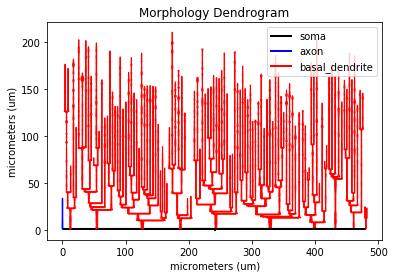

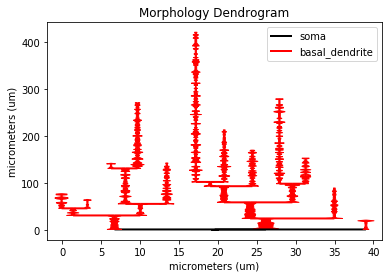

In [7]:
'''
%matplotlib notebook
neurom.viewer.draw(morph_TCcAD, mode = '3d')
neurom.viewer.draw(morph_IN, mode = '3d')
'''

%matplotlib inline
neurom.viewer.draw(morph_TCcAD, mode = 'dendrogram')
neurom.viewer.draw(morph_IN, mode = 'dendrogram')

In [2]:
class Cell:
    def __init__(self, gid, x, y, z, theta):
        self._gid = gid
        self._setup_cell()
        self.x = self.y = self.z = 0                     
        h.define_shape()
        self._rotate_z(theta)                                   
        self._set_position(x, y, z)                      
        
    def __repr__(self):
        return '{}[{}]'.format(self.name, self._gid)
    
    def _set_position(self, x, y, z):
        for sec in self.model.all:
            for i in range(sec.n3d()):
                sec.pt3dchange(i,
                               x - self.x + sec.x3d(i),
                               y - self.y + sec.y3d(i),
                               z - self.z + sec.z3d(i),
                              sec.diam3d(i))
        self.x, self.y, self.z = x, y, z
    def _rotate_z(self, theta):
        """Rotate the cell about the Z axis."""
        for sec in self.model.all:
            for i in range(sec.n3d()):
                x = sec.x3d(i)
                y = sec.y3d(i)
                c = h.cos(theta)
                s = h.sin(theta)
                xprime = x * c - y * s
                yprime = x * s + y * c
                sec.pt3dchange(i, xprime, yprime, sec.z3d(i), sec.diam3d(i))
    
class IN(Cell):
    name = 'Interneuron'
    def _setup_cell(self):
        h.load_file("cAD_ltb.hoc")
        morphology_dir = "morphologies"
        morphology_name = "IN_jy190506_A_idC.asc"
        self.model = h.cAD_ltb(morphology_dir, morphology_name)

class TC(Cell):
    name = 'TC'
    def _setup_cell(self):
        h.load_file("cAD_ltb.hoc")
        morphology_dir = "morphologies"
        morphology_name = "TC_jy160728_A_idA.asc"
        self.model = h.cAD_ltb(morphology_dir, morphology_name)


In [ ]:
IN_1 = IN(0,50,50,50,90)

In [9]:
stim = h.IClamp(IN_1.model.soma[0](0.5))
stim.dur   = 200
stim.delay = 200
stim.amp   = 0.250

In [10]:
t = h.Vector()
t.record(h._ref_t)

soma_v = h.Vector()
soma_v.record(IN_1.model.soma[0](0.5)._ref_v)

dend_v = h.Vector()
dend_v.record(IN_1.model.dend[18](0.5)._ref_v)


stim_current = h.Vector()
stim_current.record(stim._ref_i);

In [11]:
#h.finitialize(-79 * mV) what is the difference?
h.v_init = -79
h.tstop = 500
h.celsius = 34
h.run();

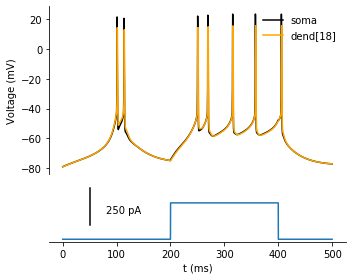

In [12]:
f, (ax0, ax1) = plt.subplots(2,1, figsize=(5,4), gridspec_kw = {'height_ratios':[3, 1]})
ax0.plot(t,soma_v, 'k', label = 'soma')
ax0.plot(t,dend_v, 'orange', label = 'dend[18]')
ax0.legend(frameon=False)
ax1.plot(t,stim_current)

ax0.set_ylabel('Voltage (mV)')
#ax0.set_ylim(-80,20)
ax0.spines['right'].set_visible(False)
ax0.spines['top'].set_visible(False)
ax0.spines['bottom'].set_visible(False)
ax0.get_xaxis().set_visible(False)


ax1.plot([50,50],[0.1,0.35],'k')
ax1.text(80,0.2,'250 pA',va='center')
ax1.set_ylabel('I (nA)')
ax1.set_xlabel('t (ms)')
#ax1.set_ylim(-0.01,0.02)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.get_yaxis().set_visible(False)
plt.tight_layout()

In [3]:
def create_n_TC(n, r):
    """n = number of cells; r = radius of circle"""
    cells = []
    for i in range(n):
        theta = i * 2 * h.PI / n
        cells.append(TC(i, h.cos(theta) * r, h.sin(theta) * r, 0, theta))
    return cells    

In [4]:
all_TCs = create_n_TC(5,100)

In [5]:
IN_1 = IN(0,0,0,0,0)

In [6]:
ps = h.PlotShape(True)
ps.show(0)

1.0

In [104]:
stim = h.NetStim() # Make a new stimulator

# Attach it to a synapse in the middle of the dendrite
# of the first cell in the network. (Named 'syn_' to avoid
# being overwritten with the 'syn' var assigned later.)
syn_oc_Br_to_oc_IN_prox = h.ExpSyn(IN_1.model.dend[0](0.1))
syn_oc_Br_to_oc_IN_dist = h.ExpSyn(IN_1.model.dend[13](0.9))
syn_oc_Br_to_oc_TC0 = h.ExpSyn(all_TCs[0].model.dend[0](0.1))
syn_oc_Br_to_oc_TC1 = h.ExpSyn(all_TCs[1].model.dend[0](0.1))
syn_oc_Br_to_oc_TC2 = h.ExpSyn(all_TCs[2].model.dend[0](0.1))
syn_oc_Br_to_oc_TC3 = h.ExpSyn(all_TCs[3].model.dend[0](0.1))
syn_oc_Br_to_oc_TC4 = h.ExpSyn(all_TCs[4].model.dend[0](0.1))


stim.number = 1
stim.start = 9

ncstim_IN_prox = h.NetCon(stim, syn_oc_Br_to_oc_IN_prox)
ncstim_IN_prox.delay = 1 * ms
ncstim_IN_prox.weight[0] = 0.04 # NetCon weight is a vector.
syn_oc_Br_to_oc_IN_prox.tau = 3 * ms

ncstim_IN_dist = h.NetCon(stim, syn_oc_Br_to_oc_IN_dist)
ncstim_IN_dist.delay = 1 * ms
ncstim_IN_dist.weight[0] = 0.04 # NetCon weight is a vector.
syn_oc_Br_to_oc_IN_dist.tau = 2 * ms

ncstim_TC0 = h.NetCon(stim, syn_oc_Br_to_oc_TC0)
ncstim_TC0.delay = 1 * ms
ncstim_TC0.weight[0] = 0.4 # NetCon weight is a vector. CHANGED TO 0.4 FOR FUN!
syn_oc_Br_to_oc_TC0.tau = 2 * ms

ncstim_TC1 = h.NetCon(stim, syn_oc_Br_to_oc_TC1)
ncstim_TC1.delay = 1 * ms
ncstim_TC1.weight[0] = 0.04 # NetCon weight is a vector.
syn_oc_Br_to_oc_TC1.tau = 2 * ms

ncstim_TC2 = h.NetCon(stim, syn_oc_Br_to_oc_TC2)
ncstim_TC2.delay = 1 * ms
ncstim_TC2.weight[0] = 0.4 # NetCon weight is a vector. CHANGED TO 0.4 FOR FUN!
syn_oc_Br_to_oc_TC2.tau = 2 * ms

ncstim_TC3 = h.NetCon(stim, syn_oc_Br_to_oc_TC3)
ncstim_TC3.delay = 1 * ms
ncstim_TC3.weight[0] = 0.04 # NetCon weight is a vector.
syn_oc_Br_to_oc_TC3.tau = 2 * ms

ncstim_TC4 = h.NetCon(stim, syn_oc_Br_to_oc_TC4)
ncstim_TC4.delay = 1 * ms
ncstim_TC4.weight[0] = 0.04 # NetCon weight is a vector.
syn_oc_Br_to_oc_TC4.tau = 2 * ms

In [105]:
print('Reversal potential = {} mV'.format(syn_oc_Br_to_oc_IN_prox.e))

Reversal potential = 0.0 mV


In [106]:
IN_soma_v = h.Vector().record(IN_1.model.soma[0](0.5)._ref_v)
IN_dend_prox_v = h.Vector().record(IN_1.model.dend[0](0.1)._ref_v)
IN_dend_dist_v = h.Vector().record(IN_1.model.dend[13](0.9)._ref_v)

TC_soma_v = h.Vector().record(all_TCs[0].model.soma[0](0.5)._ref_v)
TC_dend_v = h.Vector().record(all_TCs[0].model.dend[0](0.1)._ref_v)

t = h.Vector().record(h._ref_t)

In [82]:
h.v_init = -65
h.tstop = 50
h.celsius = 34
h.run();

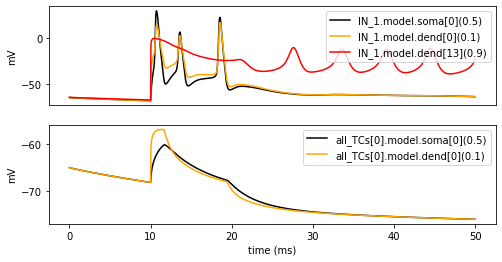

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(2, 1, 1)
IN_soma_plot = ax1.plot(t, IN_soma_v, color='black', label='IN_1.model.soma[0](0.5)')
IN_dend_prox_plot = ax1.plot(t, IN_dend_prox_v, color='orange', label='IN_1.model.dend[0](0.1)')
IN_dend_dist_plot = ax1.plot(t, IN_dend_dist_v, color='red', label='IN_1.model.dend[13](0.9)')
ax1.legend()
ax1.set_ylabel('mV')
ax1.set_xticks([]) # Use ax2's tick labels

ax2 = fig.add_subplot(2, 1, 2)
TC_soma_plot = ax2.plot(t, TC_soma_v, color='black', label='all_TCs[0].model.soma[0](0.5)')
TC_dend_plot = ax2.plot(t, TC_dend_v, color='orange', label='all_TCs[0].model.dend[0](0.1)')
ax2.legend()
ax2.set_ylabel('mV')
ax2.set_xlabel('time (ms)')
plt.show()

In [86]:
syn_oc_Br_to_oc_IN_prox_i = h.Vector().record(syn_oc_Br_to_oc_IN_prox._ref_i)

In [87]:
h.v_init = -65
h.tstop = 50
h.celsius = 34
h.run();

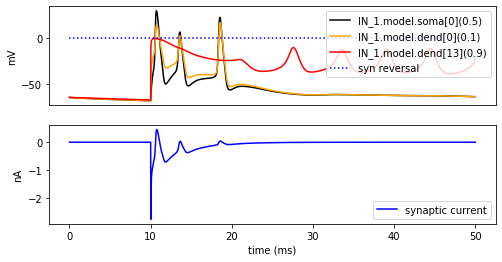

In [88]:
fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(2, 1, 1)
IN_soma_plot = ax1.plot(t, IN_soma_v, color='black', label='IN_1.model.soma[0](0.5)')
IN_dend_prox_plot = ax1.plot(t, IN_dend_prox_v, color='orange', label='IN_1.model.dend[0](0.1)')
IN_dend_dist_plot = ax1.plot(t, IN_dend_dist_v, color='red', label='IN_1.model.dend[13](0.9)')
rev_plot = ax1.plot([t[0], t[-1]], [syn_.e, syn_.e], label='syn reversal',
        color='blue', linestyle=':')
ax1.legend()
ax1.set_ylabel('mV')
ax1.set_xticks([]) # Use ax2's tick labels

ax2 = fig.add_subplot(2, 1, 2)
syn_oc_Br_to_oc_IN_prox_plot = ax2.plot(t, syn_oc_Br_to_oc_IN_prox_i, color='blue', label='synaptic current')
ax2.legend()
ax2.set_ylabel(h.units('ExpSyn.i'))
ax2.set_xlabel('time (ms)')
plt.show()

In [107]:
syns = []
netcons = []
for target in all_TCs:
    syn = h.Exp2Syn(target.model.dend[0](0.1))
    nc = h.NetCon(IN_1.model.soma[0](0.5)._ref_v, syn, sec=IN_1.model.soma[0])
    nc.weight[0] = 0.04
    nc.delay = 1
    syn.tau1 = 0.7
    syn.tau2 = 4.2
    syn.e = -80
    netcons.append(nc)
    syns.append(syn)
    
    
    
syns2 = []
netcons2 = []
for target in all_TCs:
    syn2 = h.Exp2Syn(target.model.dend[0](0.1))
    nc2 = h.NetCon(IN_1.model.dend[13](0.9)._ref_v, syn2, sec=IN_1.model.dend[13])
    nc2.weight[0] = 0.04
    nc2.delay = 0.5
    nc2.threshold = -10
    syn2.tau1 = 0.7
    syn2.tau2 = 4.2
    syn2.e = -80
    netcons2.append(nc2)
    syns2.append(syn2)

In [108]:
IN_soma_v = h.Vector().record(IN_1.model.soma[0](0.5)._ref_v)
IN_dend_prox_v = h.Vector().record(IN_1.model.dend[0](0.1)._ref_v)
IN_dend_dist_v = h.Vector().record(IN_1.model.dend[13](0.9)._ref_v)

TC0_soma_v = h.Vector().record(all_TCs[0].model.soma[0](0.5)._ref_v)
TC0_dend_v = h.Vector().record(all_TCs[0].model.dend[0](0.1)._ref_v)

TC1_soma_v = h.Vector().record(all_TCs[1].model.soma[0](0.5)._ref_v)
TC1_dend_v = h.Vector().record(all_TCs[1].model.dend[0](0.1)._ref_v)

TC2_soma_v = h.Vector().record(all_TCs[2].model.soma[0](0.5)._ref_v)
TC2_dend_v = h.Vector().record(all_TCs[2].model.dend[0](0.1)._ref_v)

TC3_soma_v = h.Vector().record(all_TCs[3].model.soma[0](0.5)._ref_v)
TC3_dend_v = h.Vector().record(all_TCs[3].model.dend[0](0.1)._ref_v)

TC4_soma_v = h.Vector().record(all_TCs[4].model.soma[0](0.5)._ref_v)
TC4_dend_v = h.Vector().record(all_TCs[4].model.dend[0](0.1)._ref_v)

t = h.Vector().record(h._ref_t)

h.finitialize(-65 * mV)
h.continuerun(100 * ms)


0.0

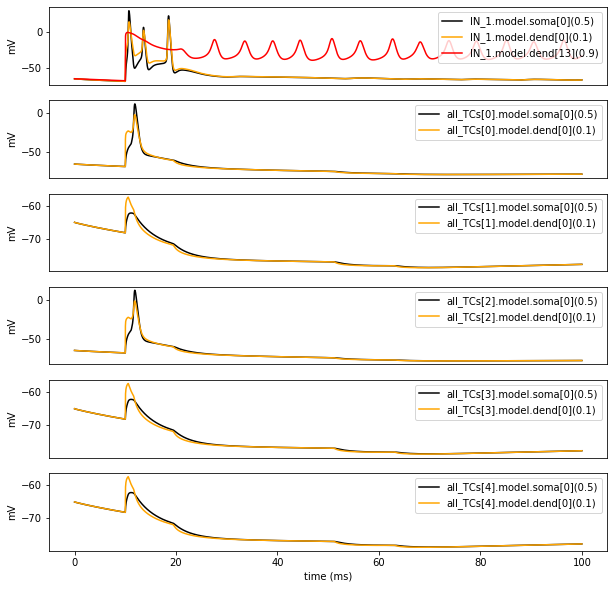

In [109]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(6, 1, 1)
IN_soma_plot = ax1.plot(t, IN_soma_v, color='black', label='IN_1.model.soma[0](0.5)')
IN_dend_prox_plot = ax1.plot(t, IN_dend_prox_v, color='orange', label='IN_1.model.dend[0](0.1)')
IN_dend_dist_plot = ax1.plot(t, IN_dend_dist_v, color='red', label='IN_1.model.dend[13](0.9)')
ax1.legend()
ax1.set_ylabel('mV')
ax1.set_xticks([]) # Use ax2's tick labels

ax2 = fig.add_subplot(6, 1, 2)
TC0_soma_plot = ax2.plot(t, TC0_soma_v, color='black', label='all_TCs[0].model.soma[0](0.5)')
TC0_dend_plot = ax2.plot(t, TC0_dend_v, color= 'orange', label='all_TCs[0].model.dend[0](0.1)')
ax2.legend()
ax2.set_ylabel('mV')
ax2.set_xticks([])

ax3 = fig.add_subplot(6,1,3)
TC1_soma_plot = ax3.plot(t, TC1_soma_v, color='black', label='all_TCs[1].model.soma[0](0.5)')
TC1_dend_plot = ax3.plot(t, TC1_dend_v, color= 'orange', label='all_TCs[1].model.dend[0](0.1)')
ax3.legend()
ax3.set_ylabel('mV')
ax3.set_xticks([])

ax4 = fig.add_subplot(6,1,4)
TC2_soma_plot = ax4.plot(t, TC2_soma_v, color='black', label='all_TCs[2].model.soma[0](0.5)')
TC2_dend_plot = ax4.plot(t, TC2_dend_v, color= 'orange', label='all_TCs[2].model.dend[0](0.1)')
ax4.legend()
ax4.set_ylabel('mV')
ax4.set_xticks([])

ax5 = fig.add_subplot(6,1,5)
TC3_soma_plot = ax5.plot(t, TC3_soma_v, color='black', label='all_TCs[3].model.soma[0](0.5)')
TC3_dend_plot = ax5.plot(t, TC3_dend_v, color= 'orange', label='all_TCs[3].model.dend[0](0.1)')
ax5.legend()
ax5.set_ylabel('mV')
ax5.set_xticks([])

ax6 = fig.add_subplot(6,1,6)
TC4_soma_plot = ax6.plot(t, TC4_soma_v, color='black', label='all_TCs[4].model.soma[0](0.5)')
TC4_dend_plot = ax6.plot(t, TC4_dend_v, color= 'orange', label='all_TCs[4].model.dend[0](0.1)')
ax6.legend()
ax6.set_ylabel('mV')
ax6.set_xlabel('time (ms)')
plt.show()

In [110]:
spike_times = [h.Vector() for nc in netcons]
for nc, spike_times_vec in zip(netcons, spike_times):
    nc.record(spike_times_vec)
    
spike_times2 = [h.Vector() for nc2 in netcons2]
for nc2, spike_times_vec2 in zip(netcons2, spike_times2):
    nc2.record(spike_times_vec2)

In [111]:
h.finitialize(-65 * mV)
h.continuerun(100 * ms)

0.0

In [123]:
for i, spike_times_vec in enumerate(spike_times):
    print('TC {}: {}'.format(i, list(spike_times_vec)))
    
for k, spike_times_vec2 in enumerate(spike_times2):
    print('TC {}: {}'.format(k, list(spike_times_vec2)))
    


TC 0: []
TC 1: []
TC 2: []
TC 3: []
TC 4: [10.600000000099932, 18.40000000009949]
TC 0: []
TC 1: []
TC 2: []
TC 3: []
TC 4: [10.050000000099963, 50.600000000102945, 62.57500000010567]


IndexError: Vector[14091]

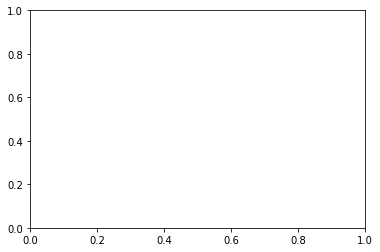

In [125]:
plt.figure()

for k, spike_times_vec2 in enumerate(spike_times2):
    plt.vlines(spike_times_vec2, k + 0.5, k + 1.5)
plt.show()

In [126]:
class Cell:
    def __init__(self, gid, x, y, z, theta):
        self._gid = gid
        self._setup_cell()
        self.x = self.y = self.z = 0                     
        h.define_shape()
        self._rotate_z(theta)                                   
        self._set_position(x, y, z)        
        
    def __repr__(self):
        return '{}[{}]'.format(self.name, self._gid)
    
    def _set_position(self, x, y, z):
        for sec in self.model.all:
            for i in range(sec.n3d()):
                sec.pt3dchange(i,
                               x - self.x + sec.x3d(i),
                               y - self.y + sec.y3d(i),
                               z - self.z + sec.z3d(i),
                              sec.diam3d(i))
        self.x, self.y, self.z = x, y, z
    def _rotate_z(self, theta):
        """Rotate the cell about the Z axis."""
        for sec in self.model.all:
            for i in range(sec.n3d()):
                x = sec.x3d(i)
                y = sec.y3d(i)
                c = h.cos(theta)
                s = h.sin(theta)
                xprime = x * c - y * s
                yprime = x * s + y * c
                sec.pt3dchange(i, xprime, yprime, sec.z3d(i), sec.diam3d(i))
    
class IN(Cell):
    name = 'Interneuron'
    def _setup_cell(self):
        h.load_file("cAD_ltb.hoc")
        morphology_dir = "morphologies"
        morphology_name = "IN_jy190506_A_idC.asc"
        self.model = h.cAD_ltb(morphology_dir, morphology_name)
        
        self._spike_detector = h.NetCon(self.model.soma[0](0.5)._ref_v, None, sec=self.model.soma[0])
        self.spike_times = h.Vector()
        self._spike_detector.record(self.spike_times)
        self._ncs = []
        self.soma_v = h.Vector().record(self.model.soma[0](0.5)._ref_v)
        
        self._release_detector = h.NetCon(self.model.dend[13](0.9)._ref_v, None, sec=self.model.dend[13])
        self.release_times = h.Vector()
        self._release_detector.record(self.release_times)
        self._ncs2 = []
        self.dend_dist_v = h.Vector().record(self.model.dend[13](0.9)._ref_v)

        self.syn_prox = h.ExpSyn(self.model.dend[0](0.1))
        self.syn_prox.tau = 2 * ms
        
        self.syn_dist = h.ExpSyn(self.model.dend[13](0.9))
        self.syn_dist.tau = 2 * ms
        

class TC(Cell):
    name = 'TC'
    def _setup_cell(self):
        h.load_file("cAD_ltb.hoc")
        morphology_dir = "morphologies"
        morphology_name = "TC_jy160728_A_idA.asc"
        self.model = h.cAD_ltb(morphology_dir, morphology_name)
        
        self.syn_Br = h.ExpSyn(self.model.dend[0](0.1))
        self.syn.tau = 2 * ms
        
        self.syn_axonal = h.Exp2Syn(self.model.dend[0](0.1))
        self.syn.tau = 2 * ms
        
        self.syn_dendritic = h.Exp2Syn(self.model.dend[0](0.1))
        self.syn.tau = 2 * ms


In [ ]:
class Ring:
    """A network of TC and IN cells where IN makes an
    axonal and dendritic synapse onto all other TCs
    """
    def __init__(self, N=5, stim_w=0.04, stim_t=9, stim_delay=1, syn_w=0.01, syn_delay=5, r=100):
        """
        :param N: Number of cells.
        :param stim_w: Weight of the stimulus
        :param stim_t: time of the stimulus (in ms)
        :param stim_delay: delay of the stimulus (in ms)
        :param syn_w: Synaptic weight
        :param syn_delay: Delay of the synapse
        :param r: radius of the network
        """ 
        self._syn_w = syn_w
        self._syn_delay = syn_delay
        self._create_cells(N, r)
        self._connect_cells()
        # add stimulus
        self._netstim = h.NetStim()
        self._netstim.number = 1
        self._netstim.start = stim_t
        self._nc = h.NetCon(self._netstim, self.cells[0].syn)
        self._nc.delay = stim_delay
        self._nc.weight[0] = stim_w
    
    def _create_cells(self, N, r):
        self.cells = []
        for i in range(N):
            theta = i * 2 * h.PI / N
            self.cells.append(BallAndStick(i, h.cos(theta) * r, h.sin(theta) * r, 0, theta))
    
    def _connect_cells(self):
        for source, target in zip(self.cells, self.cells[1:] + [self.cells[0]]):
            nc = h.NetCon(source.soma(0.5)._ref_v, target.syn, sec=source.soma)
            nc.weight[0] = self._syn_w
            nc.delay = self._syn_delay
            source._ncs.append(nc)        